# Linear and Exponential Smoothing Forecasts
## ZIP-Level Rent Forecasting & Model Evaluation (ZORI)

This notebook conducts ZIP-code–level rental forecasting using Zillow’s Observed Rent Index (ZORI).
It implements a rolling-origin cross-validation framework across multiple forecasting models—including linear trend regressions and Exponential Smoothing (ETS)—to identify the most reliable 12-month forecasting method.

After selecting the best-performing model, the notebook produces 12-month forecasts for all ZIP codes, computes a volatility metric based on historic percentage changes, and exports results for downstream visualization in the Rent Smarter application.

This workflow supports our project goal of building a dynamic, ZIP-level monthly rent forecasting tool that is transparent, scalable, and able to surface localized “good deal” opportunities for renters.

## 1. Load Required Packages & Dataset

Prepare environment, import dependencies, and load the Zillow ZORI dataset.

In [79]:
import pandas as pd
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
import numpy as np
import gcsfs
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
from matplotlib import cm
import seaborn as sns
from joblib import Parallel, delayed
import time
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning, message="divide by zero encountered in log")

In [2]:
zori= pd.read_parquet('clean_zori.parquet')
zori

,ZIP,Date,RegionID,SizeRank,RegionType,State,City,Metro,CountyName,Rent,Volatility
0,01002,2015-01-31,58197,3911,zip,MA,Amherst,"Springfield, MA",Hampshire County,2608.712894,NaN
1,01002,2015-02-28,58197,3911,zip,MA,Amherst,"Springfield, MA",Hampshire County,2608.712894,NaN
2,01002,2015-03-31,58197,3911,zip,MA,Amherst,"Springfield, MA",Hampshire County,2608.712894,NaN
3,01002,2015-04-30,58197,3911,zip,MA,Amherst,"Springfield, MA",Hampshire County,2608.712894,NaN
4,01002,2015-05-31,58197,3911,zip,MA,Amherst,"Springfield, MA",Hampshire County,2608.712894,NaN
...,...,...,...,...,...,...,...,...,...,...,...
694122,99705,2024-07-31,100380,5345,zip,AK,North Pole,"Fairbanks, AK",Fairbanks North Star Borough,1667.402103,0.009887
694123,99705,2024-08-31,100380,5345,zip,AK,North Pole,"Fairbanks, AK",Fairbanks North Star Borough,1689.103395,0.010124
694124,99705,2024-09-30,100380,5345,zip,AK,North Pole,"Fairbanks, AK",Fairbanks North Star Borough,1691.219655,0.010115
694125,99705,2024-10-31,100380,5345,zip,AK,North Pole,"Fairbanks, AK",Fairbanks North Star Borough,1687.545430,0.009841


Ensure the Date column is properly converted to a pandas datetime object.

In [3]:
zori['Date'] = pd.to_datetime(zori['Date'])

## 2. Helper Functions: Metrics & Rolling Cross-Validation
Utility functions for RMSE and rolling-origin cross-validation (for Linear and ETS models).

In [4]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

In [5]:
def rolling_cv_linear(series, horizon=3, min_train=24, step=3, max_folds=12, seasonal=False, poly_degree=1, lr_kwargs=None):
    ''' 
    Return the average RMSEs for linear models.
    '''
    lr_kwargs = lr_kwargs or {}
    series = series.dropna().astype(float)
    n = len(series)
    if n < min_train + horizon:
        return np.nan, np.nan

    # choosing a limited set of origin points to reduce computation time
    origins = list(range(min_train, n - horizon + 1, step))
    if len(origins) > max_folds:
        # keep the last max_folds origins for recent data emphasis
        origins = origins[-max_folds:]

    rmse_lin = []
    mae_lin = []

    # Build model once (we’ll refit it each fold)
    # X is just a time index 0,1,2,...; polynomial adds nonlinear trend if desired
    def make_model():
        if poly_degree > 1:
            return make_pipeline(
                PolynomialFeatures(poly_degree, include_bias=False),
                LinearRegression(**lr_kwargs)
            )
        else:
            return LinearRegression(**lr_kwargs)

    for i in origins:
        train = series.iloc[:i]
        test  = series.iloc[i:i+horizon]

        # Time index as predictor
        X_train = np.arange(len(train)).reshape(-1, 1)
        X_future = np.arange(len(train), len(train)+horizon).reshape(-1, 1)

        model = make_model()
        model.fit(X_train, train.values)
        pred = model.predict(X_future)

        rmse_lin.append(rmse(test, pred))
        mae_lin.append(mean_absolute_error(test, pred))

    return float(np.mean(rmse_lin)), float(np.mean(mae_lin))

In [6]:
def rolling_cv_ets(series, horizon=3, min_train=48, step=3, max_folds=12, trend='add', damped_trend=False, seasonal=None, 
                   seasonal_periods=None, use_boxcox=None, remove_bias=False, initialization_method='estimated', fit_kwargs=None):
    ''' 
    Return the average RMSEs for ETS models.
    '''
    fit_kwargs = fit_kwargs or {}

    # Clean series
    series = series.dropna().astype(float).reset_index(drop=True)
    n = len(series)
    if n < min_train + horizon:
        return np.nan, np.nan

    # Rolling origins
    origins = list(range(min_train, n - horizon + 1, step))
    if len(origins) > max_folds:
        origins = origins[-max_folds:]

    rmse_ets = []
    mae_ets  = []

    # Default seasonal_periods if needed
    sp = seasonal_periods
    if seasonal is not None and sp is None:
        sp = 12  # assuming monthly data

    for i in origins:
        train = series.iloc[:i]
        test  = series.iloc[i:i+horizon]
        if len(test) < horizon:
            continue

        try:
            model = ExponentialSmoothing(
                train,
                trend=trend,
                damped_trend=damped_trend,
                seasonal=seasonal,
                seasonal_periods=sp,
                initialization_method=initialization_method,
            )

            # Build full fit kwargs once
            kwargs = dict(remove_bias=remove_bias)
            if use_boxcox is not None:
                kwargs['use_boxcox'] = use_boxcox
            kwargs.update(fit_kwargs)

            # Silence that specific RuntimeWarning *around* the fit
            with warnings.catch_warnings():
                warnings.filterwarnings(
                    "ignore",
                    message="divide by zero encountered in log",
                    category=RuntimeWarning
                )
                ets_fit = model.fit(**kwargs)

            pred = ets_fit.forecast(horizon)

            rmse_ets.append(rmse(test, pred))
            mae_ets.append(mean_absolute_error(test, pred))

        except Exception:
            # If something fails for this fold, skip it
            continue

    if len(rmse_ets) == 0:
        return np.nan, np.nan

    return float(np.mean(rmse_ets)), float(np.mean(mae_ets))

In [7]:
def eval_zip(zip_code, grp, model_func, model_kwargs):
    series = grp.sort_values('Date')['Rent']
    
    dates = grp['Date'].values # keep Date column for plotting later

    
    series = grp['Rent'].reset_index(drop=True) # allows ETS a simple RangeIndex
    
    rmse_cv, mae_cv = model_func(
        series=series,
        **model_kwargs
    )
    
    return {
        'ZIP': zip_code,
        'rmse_cv': rmse_cv,
        'mae_cv': mae_cv
    }

In [8]:
# This will be needed for the forecasts
zip_groups = zori.groupby('ZIP')

## 3. Rolling CV: Linear & Polynomial Trend Models
Run rolling cross-validation across all ZIP codes using linear and polynomial trend specifications.

In [9]:
configs = [
    {'horizon': 12, 'min_train': 24, 'step': 3, 'max_folds': 12, 'poly_degree': 1}, # baseline
]

linear_results = []

for cfg in configs:
    print(f"Running config: {cfg}")
    start = time.perf_counter()

    results = Parallel(n_jobs=-1, verbose=10)(
        delayed(eval_zip)(zip_code, grp, rolling_cv_linear, cfg)
        for zip_code, grp in zip_groups
    )

    end = time.perf_counter()
    elapsed = end - start  # seconds

    df_out = pd.DataFrame(results)
    df_out['config'] = str(cfg)
    df_out['config_runtime_sec'] = elapsed  # same value repeated for all rows of this config

    linear_results.append(df_out)

cv_linear_results = pd.concat(linear_results, ignore_index=True)

Running config: {'horizon': 12, 'min_train': 24, 'step': 3, 'max_folds': 12, 'poly_degree': 1}


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    1.8s
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    1.8s
[Parallel(n_jobs=-1)]: Done  16 tasks      | elapsed:    1.8s
[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed:    1.9s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.17995010016046525s.) Setting batch_size=2.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    1.9s
[Parallel(n_jobs=-1)]: Done  45 tasks      | elapsed:    1.9s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.023152828216552734s.) Setting batch_size=4.
[Parallel(n_jobs=-1)]: Done  64 tasks      | elapsed:    1.9s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.028277873992919922s.) Setting batch_size=8.
[Parallel(n_jobs=-1)]: Done 100 tasks      | elapsed:    2.0s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.07157206535339355s.) Setting batch_size=16.
[Parallel(n_jobs=-1)]: Done 160 tasks    

In [10]:
cv_linear_results

,ZIP,rmse_cv,mae_cv,config,config_runtime_sec
0,01002,2.437100e+01,1.780034e+01,"{'horizon': 12, 'min_train': 24, 'step': 3, 'm...",7.276268
1,01103,3.221127e-13,3.221127e-13,"{'horizon': 12, 'min_train': 24, 'step': 3, 'm...",7.276268
2,01201,3.435166e+01,3.000288e+01,"{'horizon': 12, 'min_train': 24, 'step': 3, 'm...",7.276268
3,01420,6.368383e+01,5.854296e+01,"{'horizon': 12, 'min_train': 24, 'step': 3, 'm...",7.276268
4,01440,7.579123e-14,7.579123e-14,"{'horizon': 12, 'min_train': 24, 'step': 3, 'm...",7.276268
...,...,...,...,...,...
5828,99517,1.303048e+02,1.233865e+02,"{'horizon': 12, 'min_train': 24, 'step': 3, 'm...",7.276268
5829,99577,1.579564e+02,1.516982e+02,"{'horizon': 12, 'min_train': 24, 'step': 3, 'm...",7.276268
5830,99654,2.929643e+01,2.494057e+01,"{'horizon': 12, 'min_train': 24, 'step': 3, 'm...",7.276268
5831,99701,1.050348e+01,7.863583e+00,"{'horizon': 12, 'min_train': 24, 'step': 3, 'm...",7.276268


In [11]:
linear_runtime_summary = (
    cv_linear_results[['config', 'config_runtime_sec']]
    .drop_duplicates()
    .reset_index(drop=True)
)
linear_runtime_summary

,config,config_runtime_sec
0,"{'horizon': 12, 'min_train': 24, 'step': 3, 'm...",7.276268


## 4. Rolling CV: ETS (Exponential Smoothing) Models
Evaluate several ETS configurations (no seasonality, additive trend, additive seasonality, etc.) using rolling-origin cross-validation.

In [12]:
# create the configurations
common_cv_kwargs = {
    'horizon': 3,
    'min_train': 48,
    'step': 3,
    'max_folds': 12
}

ets_configs = [
    {
        'name': 'ETS_add_no_season',
        'trend': 'add',
        'damped_trend': False,
        'seasonal': None,
        'seasonal_periods': None
    },
    {
        'name': 'ETS_add_seasonal',
        'trend': 'add',
        'damped_trend': False,
        'seasonal': 'add',
        'seasonal_periods': 12      # monthly data
    },
    {
        'name': 'ETS_damped_add_seasonal',
        'trend': 'add',
        'damped_trend': True,
        'seasonal': 'add',
        'seasonal_periods': 12
    }
]

In [13]:
all_ets_results = []

for cfg in ets_configs:
    print(f"Running ETS config: {cfg['name']}")
    
    # merge common CV kwargs with model-specific ones
    model_kwargs = {**common_cv_kwargs,
                    'trend': cfg['trend'],
                    'damped_trend': cfg['damped_trend'],
                    'seasonal': cfg['seasonal'],
                    'seasonal_periods': cfg['seasonal_periods']}
    
    start = time.perf_counter()
    
    results = Parallel(n_jobs=-1, backend='threading', verbose=10)(
        delayed(eval_zip)(zip_code, grp, rolling_cv_ets, model_kwargs)
        for zip_code, grp in zip_groups
    )
    
    elapsed = time.perf_counter() - start
    
    df_out = pd.DataFrame(results)
    df_out['model'] = cfg['name']
    df_out['model_runtime_sec'] = elapsed  # total time for that config
    
    all_ets_results.append(df_out)

ets_cv_results = pd.concat(all_ets_results, ignore_index=True)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.


Running ETS config: ETS_add_no_season


[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    0.6s
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    0.9s
[Parallel(n_jobs=-1)]: Done  16 tasks      | elapsed:    1.4s
[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed:    2.1s
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    2.6s
[Parallel(n_jobs=-1)]: Done  45 tasks      | elapsed:    3.4s
[Parallel(n_jobs=-1)]: Done  56 tasks      | elapsed:    4.1s
[Parallel(n_jobs=-1)]: Done  69 tasks      | elapsed:    5.1s
[Parallel(n_jobs=-1)]: Done  82 tasks      | elapsed:    6.0s
[Parallel(n_jobs=-1)]: Done  97 tasks      | elapsed:    7.1s
[Parallel(n_jobs=-1)]: Done 112 tasks      | elapsed:    8.1s
[Parallel(n_jobs=-1)]: Done 129 tasks      | elapsed:    9.2s
[Parallel(n_jobs=-1)]: Done 146 tasks      | elapsed:   10.5s
[Parallel(n_jobs=-1)]: Done 165 tasks      | elapsed:   11.6s
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:   12.9s
[Parallel(n_jobs=-1)]: Done 205 tasks      | elapsed:   14.4s
[Paralle

Running ETS config: ETS_add_seasonal


[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    3.0s
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    5.1s
[Parallel(n_jobs=-1)]: Done  16 tasks      | elapsed:    7.4s
[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed:   11.4s
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:   14.5s
[Parallel(n_jobs=-1)]: Done  45 tasks      | elapsed:   19.0s
[Parallel(n_jobs=-1)]: Done  56 tasks      | elapsed:   23.6s
[Parallel(n_jobs=-1)]: Done  69 tasks      | elapsed:   29.0s
[Parallel(n_jobs=-1)]: Done  82 tasks      | elapsed:   34.5s
[Parallel(n_jobs=-1)]: Done  97 tasks      | elapsed:   40.5s
[Parallel(n_jobs=-1)]: Done 112 tasks      | elapsed:   46.9s
[Parallel(n_jobs=-1)]: Done 129 tasks      | elapsed:   53.9s
[Parallel(n_jobs=-1)]: Done 146 tasks      | elapsed:  1.0min
[Parallel(n_jobs=-1)]: Done 165 tasks      | elapsed:  1.2min
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:  1.3min
[Parallel(n_jobs=-1)]: Done 205 tasks      | elapsed:  1.4min
[Paralle

Running ETS config: ETS_damped_add_seasonal


[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    2.7s
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    5.3s
[Parallel(n_jobs=-1)]: Done  16 tasks      | elapsed:    6.6s
[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed:   11.5s
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:   15.0s
[Parallel(n_jobs=-1)]: Done  45 tasks      | elapsed:   18.6s
[Parallel(n_jobs=-1)]: Done  56 tasks      | elapsed:   22.6s
[Parallel(n_jobs=-1)]: Done  69 tasks      | elapsed:   28.5s
[Parallel(n_jobs=-1)]: Done  82 tasks      | elapsed:   32.9s
[Parallel(n_jobs=-1)]: Done  97 tasks      | elapsed:   39.0s
[Parallel(n_jobs=-1)]: Done 112 tasks      | elapsed:   45.0s
[Parallel(n_jobs=-1)]: Done 129 tasks      | elapsed:   51.3s
[Parallel(n_jobs=-1)]: Done 146 tasks      | elapsed:   58.1s
[Parallel(n_jobs=-1)]: Done 165 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:  1.2min
[Parallel(n_jobs=-1)]: Done 205 tasks      | elapsed:  1.4min
[Paralle

In [14]:
# compare models per zip
ets_rmse_wide = (
    ets_cv_results
    .pivot(index='ZIP', columns='model', values='rmse_cv')
    .reset_index()
)
ets_rmse_wide

model,ZIP,ETS_add_no_season,ETS_add_seasonal,ETS_damped_add_seasonal
0,01002,3.846064e+01,35.250433,3.011707e+01
1,01103,2.273737e-13,0.000000,2.273737e-13
2,01201,1.248488e+01,12.646334,1.341937e+01
3,01420,1.815657e+01,18.914988,1.942864e+01
4,01440,1.312743e-13,0.000000,0.000000e+00
...,...,...,...,...
5828,99517,3.072981e+01,31.489341,3.152472e+01
5829,99577,3.884537e+01,36.958045,3.698056e+01
5830,99654,1.432872e+01,13.908073,1.493633e+01
5831,99701,1.103758e+01,10.610507,9.741766e+00


## 5. Load CV Results & Compare Models
Bring in linear and ETS CV summaries, merge them, and compute average RMSE performance.

In [30]:
# Rename columns
cv_linear_results = cv_linear_results.rename(columns={
    'rmse_linear': 'rmse_cv',
    'mae_linear': 'mae_cv',
    'config_runtime_sec':'model_runtime_sec'
})
cv_linear_results['model'] = 'Linear'

In [31]:
ets_cv_results = ets_cv_results.rename(columns={
    'rmse_ets': 'rmse_cv',
    'mae_ets': 'mae_cv'
})

In [33]:
# stack them together
all_cv = pd.concat(
    [cv_linear_results, ets_cv_results],
    ignore_index=True
)
all_cv.drop(columns=['config'], inplace=True)
all_cv

,ZIP,rmse_cv,mae_cv,model_runtime_sec,model
0,01002,2.437100e+01,1.780034e+01,7.276268,Linear
1,01103,3.221127e-13,3.221127e-13,7.276268,Linear
2,01201,3.435166e+01,3.000288e+01,7.276268,Linear
3,01420,6.368383e+01,5.854296e+01,7.276268,Linear
4,01440,7.579123e-14,7.579123e-14,7.276268,Linear
...,...,...,...,...,...
23327,99517,3.152472e+01,2.912797e+01,2311.775030,ETS_damped_add_seasonal
23328,99577,3.698056e+01,3.262217e+01,2311.775030,ETS_damped_add_seasonal
23329,99654,1.493633e+01,1.333274e+01,2311.775030,ETS_damped_add_seasonal
23330,99701,9.741766e+00,8.395314e+00,2311.775030,ETS_damped_add_seasonal


In [34]:
best_by_zip = (
    all_cv
    .loc[all_cv.groupby('ZIP')['rmse_cv'].idxmin()]
    .reset_index(drop=True)
)
best_by_zip

,ZIP,rmse_cv,mae_cv,model_runtime_sec,model
0,01002,24.371005,17.800341,7.276268,Linear
1,01103,0.000000,0.000000,2288.495780,ETS_add_seasonal
2,01201,12.484884,10.940658,412.269966,ETS_add_no_season
3,01420,18.156567,16.365434,412.269966,ETS_add_no_season
4,01440,0.000000,0.000000,2288.495780,ETS_add_seasonal
...,...,...,...,...,...
5828,99517,30.729814,28.382587,412.269966,ETS_add_no_season
5829,99577,36.958045,32.688896,2288.495780,ETS_add_seasonal
5830,99654,13.908073,12.551956,2288.495780,ETS_add_seasonal
5831,99701,9.741766,8.395314,2311.775030,ETS_damped_add_seasonal


In [35]:
best_counts = best_by_zip['model'].value_counts()
best_counts

model
ETS_add_no_season          2884
ETS_damped_add_seasonal    1847
Linear                      735
ETS_add_seasonal            367
Name: count, dtype: int64

In [36]:
best_pct = (best_counts / len(best_by_zip)) * 100
best_pct

model
ETS_add_no_season          49.442825
ETS_damped_add_seasonal    31.664667
Linear                     12.600720
ETS_add_seasonal            6.291788
Name: count, dtype: float64

In [37]:
all_cv_runtime_summary = (
    all_cv[['model', 'model_runtime_sec']]
    .drop_duplicates()
    .reset_index(drop=True)
)
all_cv_runtime_summary

,model,model_runtime_sec
0,Linear,7.276268
1,ETS_add_no_season,412.269966
2,ETS_add_seasonal,2288.495780
3,ETS_damped_add_seasonal,2311.775030


In [38]:
# average RMSE by model
avg_rmse_by_model = (
    all_cv
    .groupby('model')['rmse_cv']
    .mean()
    .sort_values()
)

avg_rmse_by_model

model
ETS_add_no_season           23.953852
ETS_damped_add_seasonal     24.043325
ETS_add_seasonal            24.968353
Linear                     106.807254
Name: rmse_cv, dtype: float64

## 6. RMSE by Model
Aggregate CV performance to produce model-level summaries. Generate a heatmap visualizing average test RMSE by state and model, a bar chart detailing which model achieved the lowest RMSE most often across all ZIP codes, RMSE distribution boxplot by model, and Volatility vs Forecast scatterplot.

In [49]:
zip_state = zori[['ZIP', 'State']].drop_duplicates()
avg_RMSE_by_state = all_cv.merge(zip_state, on='ZIP', how='left') # get the state back
avg_RMSE_by_state

,ZIP,rmse_cv,mae_cv,model_runtime_sec,model,State
0,01002,2.437100e+01,1.780034e+01,7.276268,Linear,MA
1,01103,3.221127e-13,3.221127e-13,7.276268,Linear,MA
2,01201,3.435166e+01,3.000288e+01,7.276268,Linear,MA
3,01420,6.368383e+01,5.854296e+01,7.276268,Linear,MA
4,01440,7.579123e-14,7.579123e-14,7.276268,Linear,MA
...,...,...,...,...,...,...
23327,99517,3.152472e+01,2.912797e+01,2311.775030,ETS_damped_add_seasonal,AK
23328,99577,3.698056e+01,3.262217e+01,2311.775030,ETS_damped_add_seasonal,AK
23329,99654,1.493633e+01,1.333274e+01,2311.775030,ETS_damped_add_seasonal,AK
23330,99701,9.741766e+00,8.395314e+00,2311.775030,ETS_damped_add_seasonal,AK


In [50]:
avg_RMSE_by_state = (
    avg_RMSE_by_state
    .groupby(['State', 'model'])['rmse_cv']
    .mean()
    .reset_index()
)

avg_RMSE_by_state.head()

,State,model,rmse_cv
0,AK,ETS_add_no_season,17.508553
1,AK,ETS_add_seasonal,17.900909
2,AK,ETS_damped_add_seasonal,18.177403
3,AK,Linear,84.106555
4,AL,ETS_add_no_season,14.275283


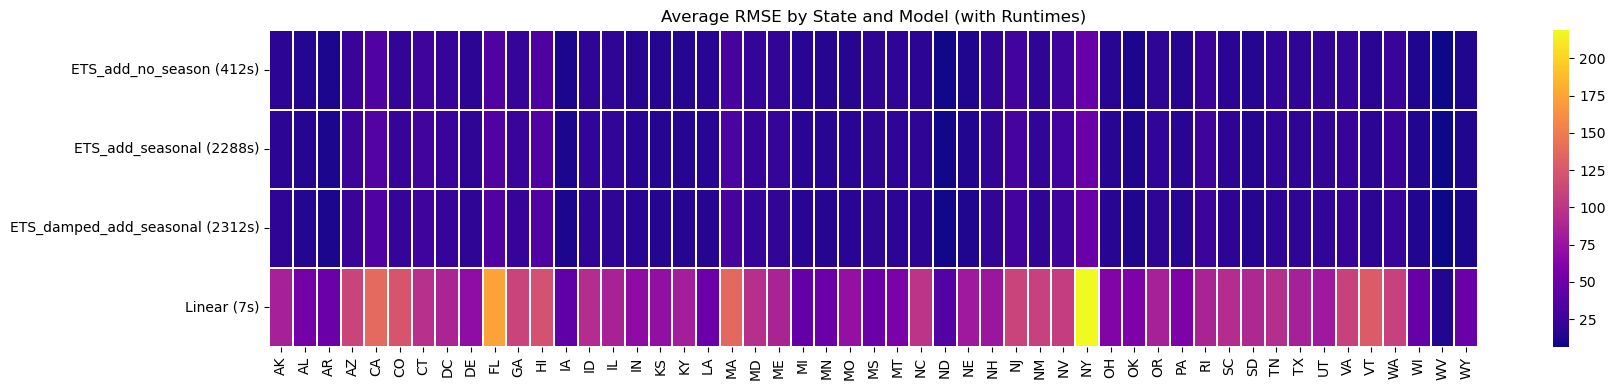

In [75]:
# Heatmap for each model
heat_df = avg_RMSE_by_state.pivot(
    index='State',
    columns='model',
    values='rmse_cv'
)

runtime_lookup = (
    all_cv_runtime_summary
    .set_index('model')['model_runtime_sec']
)

heat_df_wide = heat_df.T   # transpose

heat_df_wide.index = [
    f"{model} ({runtime_lookup[model]:.0f}s)"
    for model in heat_df_wide.index
]

plt.figure(figsize=(18, 4))   # wide, short
sns.heatmap(
    heat_df_wide,
    annot=False,
    cmap='plasma',
    linewidths=0.3
)

plt.title("Average RMSE by State and Model (with Runtimes)")
plt.xlabel("")
plt.ylabel("")
plt.tight_layout()
plt.show()

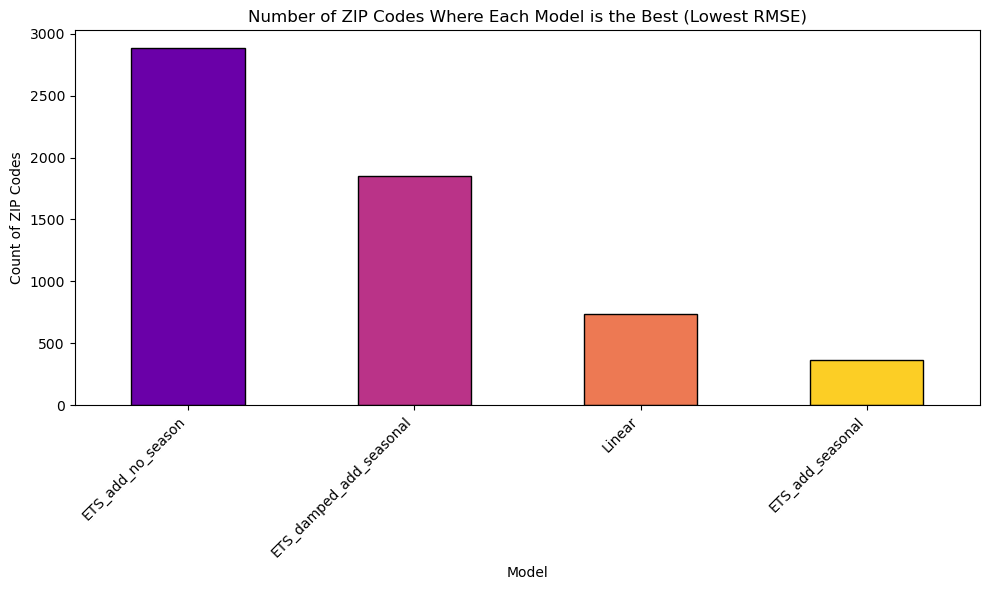

In [81]:
winners = all_cv.loc[
    all_cv.groupby('ZIP')['rmse_cv'].idxmin()
]

# Count winners by model
winner_counts = winners['model'].value_counts().sort_values(ascending=False)

# Create discrete colors from plasma
num_models = len(winner_counts)
plasma_colors = cm.plasma(np.linspace(0.2, 0.9, num_models))

plt.figure(figsize=(10, 6))
winner_counts.plot(kind='bar', edgecolor='black', color=plasma_colors)
plt.title("Number of ZIP Codes Where Each Model is the Best (Lowest RMSE)")
plt.ylabel("Count of ZIP Codes")
plt.xlabel("Model")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

/var/folders/v6/rt7shrqx5sldb75bkwymnhlw0000gp/T/ipykernel_37098/3531471691.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


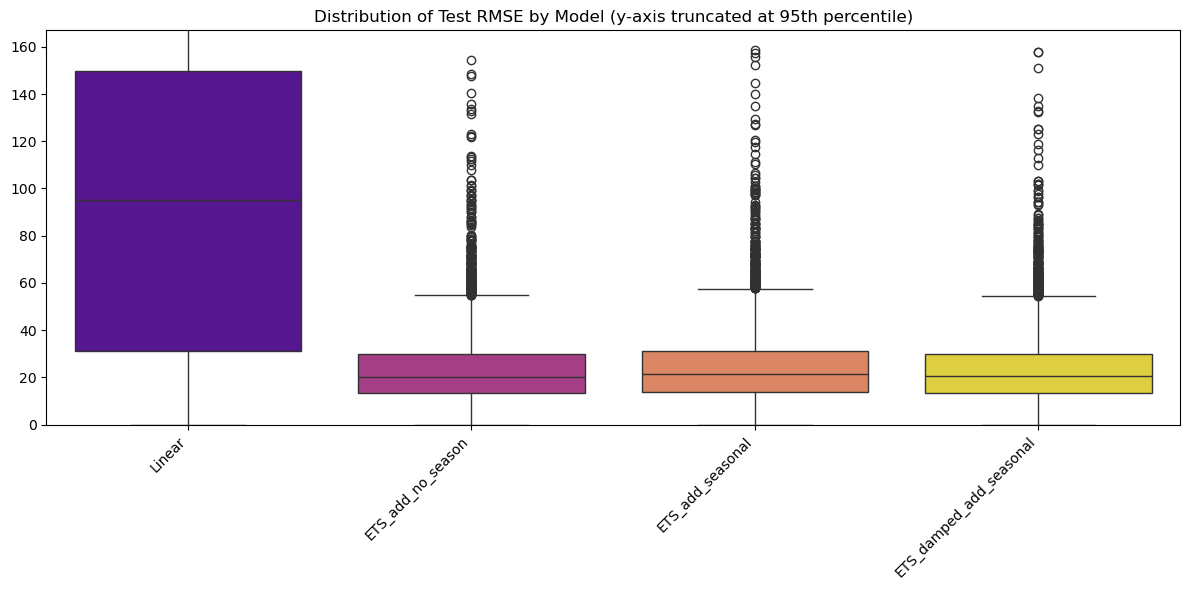

In [91]:
# Create discrete color palette from plasma
models = all_cv['model'].unique()
plasma_palette = [cm.plasma(i) for i in np.linspace(0.15, 0.95, len(models))]

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=all_cv,
    x='model',
    y='rmse_cv',
    palette=plasma_palette
)

upper = all_cv['rmse_cv'].quantile(0.95)
plt.ylim(0, upper)

plt.title("Distribution of Test RMSE by Model (y-axis truncated at 95th percentile)")
plt.xlabel("")
plt.ylabel("")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [63]:
zip_volatility = (
    zori.groupby('ZIP')['pct_change']
    .std()
    .reset_index()
    .rename(columns={'pct_change': 'Volatility'})
)

zip_volatility

,ZIP,Volatility
0,01002,0.005530
1,01103,0.000145
2,01201,0.005718
3,01420,0.005090
4,01440,0.000871
...,...,...
5828,99517,0.008272
5829,99577,0.011151
5830,99654,0.005011
5831,99701,0.004119


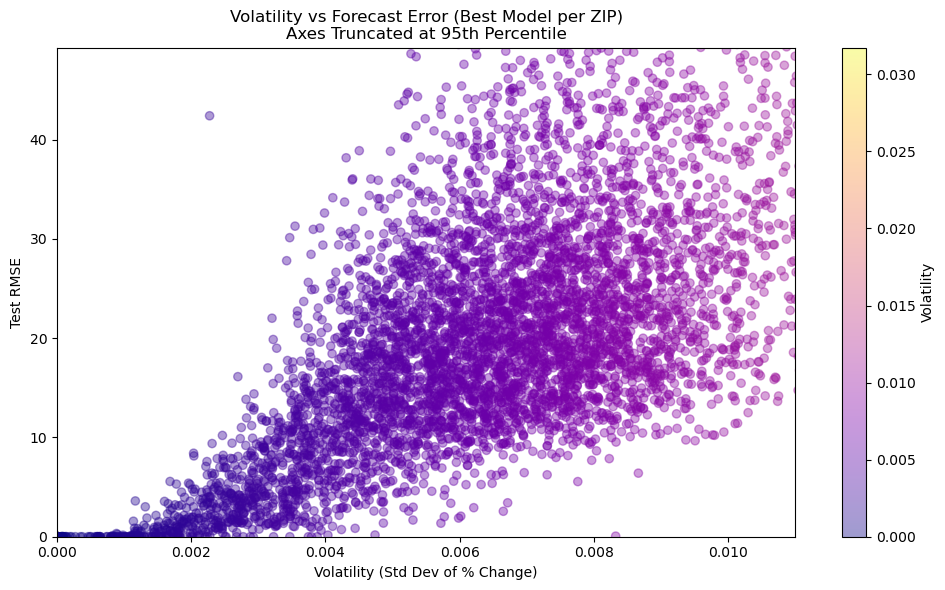

,ZIP,rmse_cv,mae_cv,model_runtime_sec,model,Volatility
0,01002,24.371005,17.800341,7.276268,Linear,0.005530
1,01103,0.000000,0.000000,2288.495780,ETS_add_seasonal,0.000145
2,01201,12.484884,10.940658,412.269966,ETS_add_no_season,0.005718
3,01420,18.156567,16.365434,412.269966,ETS_add_no_season,0.005090
4,01440,0.000000,0.000000,2288.495780,ETS_add_seasonal,0.000871


In [93]:
vol_rmse = best_by_zip.merge(zip_volatility, on='ZIP', how='left').dropna(subset=['Volatility'])

# Determine percentiles to cap axes
vol_cap = vol_rmse['Volatility'].quantile(0.95)
rmse_cap = vol_rmse['rmse_cv'].quantile(0.95)

plt.figure(figsize=(10, 6))
plt.scatter(
    vol_rmse['Volatility'],
    vol_rmse['rmse_cv'],
    c=vol_rmse['Volatility'],
    alpha=0.4,
    cmap='plasma'
)
plt.colorbar(label='Volatility')
plt.xlim(0, vol_cap)
plt.ylim(0, rmse_cap)
plt.title("Volatility vs Forecast Error (Best Model per ZIP)\nAxes Truncated at 95th Percentile")
plt.xlabel("Volatility (Std Dev of % Change)")
plt.ylabel("Test RMSE")
plt.tight_layout()
plt.show()

vol_rmse.head()


## 7. Final Model Selection & Forecasting
Fit the chosen final model (ETS with additive trend, no seasonality) for each ZIP and produce a 12-month forecast.

In [59]:
%time
    
rows = []

for zip_code, grp in zip_groups:
    grp = grp.sort_values('Date')

    series = grp['Rent'].reset_index(drop=True)

    # fit final ETS_add_no_season model
    model = ExponentialSmoothing(
        series,
        trend='add',
        damped_trend=False,
        seasonal=None,
        seasonal_periods=None,
        initialization_method='estimated'
    ).fit()

    # 12-month forecast
    forecast = model.forecast(12)

    # future dates
    last_date = grp['Date'].max()
    forecast_dates = pd.date_range(
        last_date + pd.offsets.MonthEnd(1),
        periods=12,
        freq='ME'
    )

    # build per-ZIP forecast rows
    rows.append(pd.DataFrame({
        'ZIP': zip_code,
        'Date': forecast_dates,
        'Forecast_Rent': forecast
    }))

# combine all ZIPs
final_forecast = pd.concat(rows, ignore_index=True)

final_forecast.head()

CPU times: user 3 μs, sys: 1e+03 ns, total: 4 μs
Wall time: 6.91 μs


,ZIP,Date,Forecast_Rent
0,01002,2024-12-31,2811.595041
1,01002,2025-01-31,2838.603089
2,01002,2025-02-28,2865.611138
3,01002,2025-03-31,2892.619186
4,01002,2025-04-30,2919.627234


## 8. Compute Volatility Metric
Create ZIP-level volatility using percent-change standard deviation. Attach volatility scores to future forecast rows.

In [62]:
zori['pct_change'] = (
    zori.groupby('ZIP')['Rent']
    .pct_change()
)

zori

,ZIP,Date,RegionID,SizeRank,RegionType,State,City,Metro,CountyName,Rent,Volatility,pct_change
0,01002,2015-01-31,58197,3911,zip,MA,Amherst,"Springfield, MA",Hampshire County,2608.712894,NaN,NaN
1,01002,2015-02-28,58197,3911,zip,MA,Amherst,"Springfield, MA",Hampshire County,2608.712894,NaN,0.000000
2,01002,2015-03-31,58197,3911,zip,MA,Amherst,"Springfield, MA",Hampshire County,2608.712894,NaN,0.000000
3,01002,2015-04-30,58197,3911,zip,MA,Amherst,"Springfield, MA",Hampshire County,2608.712894,NaN,0.000000
4,01002,2015-05-31,58197,3911,zip,MA,Amherst,"Springfield, MA",Hampshire County,2608.712894,NaN,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
694122,99705,2024-07-31,100380,5345,zip,AK,North Pole,"Fairbanks, AK",Fairbanks North Star Borough,1667.402103,0.009887,0.015288
694123,99705,2024-08-31,100380,5345,zip,AK,North Pole,"Fairbanks, AK",Fairbanks North Star Borough,1689.103395,0.010124,0.013015
694124,99705,2024-09-30,100380,5345,zip,AK,North Pole,"Fairbanks, AK",Fairbanks North Star Borough,1691.219655,0.010115,0.001253
694125,99705,2024-10-31,100380,5345,zip,AK,North Pole,"Fairbanks, AK",Fairbanks North Star Borough,1687.545430,0.009841,-0.002173


In [64]:
final_forecast['ZIP'] = final_forecast['ZIP'].astype(str)
zip_volatility['ZIP'] = zip_volatility['ZIP'].astype(str)

final_forecast = final_forecast.merge(zip_volatility, on='ZIP', how='left')

final_forecast

,ZIP,Date,Forecast_Rent,Volatility
0,01002,2024-12-31,2811.595041,0.005530
1,01002,2025-01-31,2838.603089,0.005530
2,01002,2025-02-28,2865.611138,0.005530
3,01002,2025-03-31,2892.619186,0.005530
4,01002,2025-04-30,2919.627234,0.005530
...,...,...,...,...
69991,99705,2025-07-31,1706.969913,0.003776
69992,99705,2025-08-31,1710.849625,0.003776
69993,99705,2025-09-30,1714.729336,0.003776
69994,99705,2025-10-31,1718.609047,0.003776


## 9. Export Final Forecast Dataset
Save the full forecast + volatility dataset as a Parquet file and CSV format.

In [66]:
%%time

horizons = np.array([3, 6, 9, 12], dtype=int)

af = final_forecast.sort_values(['ZIP', 'Date']).copy()

af['step'] = af.groupby('ZIP').cumcount() + 1
    
summary = (
    af.loc[af['step'].isin(horizons), ['ZIP', 'step', 'Forecast_Rent', 'Volatility']]
      .rename(columns={'step': 'Forecast_Month', 'ZIP': 'ZipCode'})
      .astype({'Forecast_Month':'int16'})
      .sort_values(['ZipCode','Forecast_Month'])
      .reset_index(drop=True)
)

summary.head()

CPU times: user 26.9 ms, sys: 7.43 ms, total: 34.3 ms
Wall time: 34.3 ms


,ZipCode,Forecast_Month,Forecast_Rent,Volatility
0,01002,3,2865.611138,0.005530
1,01002,6,2946.635283,0.005530
2,01002,9,3027.659428,0.005530
3,01002,12,3108.683573,0.005530
4,01103,3,1610.983370,0.000145


In [67]:
summary.describe()

,Forecast_Month,Forecast_Rent,Volatility
count,23332.000000,23332.000000,23332.000000
mean,7.500000,2047.985670,0.006610
std,3.354174,1527.913221,0.002718
min,3.000000,607.063300,0.000000
25%,5.250000,1500.766603,0.004910
50%,7.500000,1849.062837,0.006605
75%,9.750000,2360.677876,0.008205
max,12.000000,80570.622008,0.031726


In [69]:
summary.to_parquet(
    'ets_forecast.parquet',
    compression='snappy',
    index=False,
)

In [70]:
summary.to_csv('ets_forecast.csv')